# 과제 3-1. 피처 파이프라인

In [1]:
import sys
sys.path.append("..")
import os
import numpy as np
import pandas as pd
import lightgbm as lgb
from src.backtest import rolling_backtest
from src.features import build_features
from src.metrics import compute_naive_denominators, score_backtest

data = pd.read_csv(
    "../Data/processed/subset_17_buildings_Impulation.csv",
    encoding="utf-8", index_col=0, parse_dates=True,
)
subset = pd.read_csv("../Data/raw/subset_17_buildings.csv", encoding="utf-8")

feat_demo = build_features(data, horizon=24)
feat_demo168 = build_features(data, horizon=168)

print("데이터 shape:", data.shape)
print("horizon=24  피처 shape:", feat_demo.shape, "| lag 컬럼:", [c for c in feat_demo.columns if c.startswith("lag_")])
print("horizon=168 피처 shape:", feat_demo168.shape, "| lag 컬럼:", [c for c in feat_demo168.columns if c.startswith("lag_")])


데이터 shape: (17544, 17)
horizon=24  피처 shape: (298248, 23) | lag 컬럼: ['lag_24', 'lag_48', 'lag_168', 'lag_336']
horizon=168 피처 shape: (298248, 21) | lag 컬럼: ['lag_168', 'lag_336']


# 과제 3-2. Global model 학습

In [ ]:
LGB_PARAMS = dict(objective="regression", num_leaves=127, learning_rate=0.08,
                   n_estimators=300, min_child_samples=10, verbosity=-1)
LGB_PARAMS_LOCAL = dict(objective="regression", num_leaves=31, learning_rate=0.05,
                         n_estimators=100, min_child_samples=20, verbosity=-1)

def make_global_fns(feat_horizon, lgb_params=LGB_PARAMS):
    """Global 모델: 17개 건물을 하나의 LightGBM으로 학습(건물=범주형 피처).
    feat_horizon은 피처 생성 시 lag 최소값 제약으로 쓰인다."""
    def model_fn(train_df):
        feat = build_features(train_df, feat_horizon).dropna(subset=["y"])
        X = feat.drop(columns=["timestamp", "y"]).copy()
        X["building"] = X["building"].astype("category")
        model = lgb.LGBMRegressor(**lgb_params)
        model.fit(X, feat["y"], categorical_feature=["building"])
        return {"model": model, "train_df": train_df, "columns": X.columns.tolist()}

    def predict_fn(state, horizon):
        train_df = state["train_df"]
        future_index = pd.date_range(train_df.index[-1] + pd.Timedelta(hours=1), periods=horizon, freq="h")
        extended = pd.concat([train_df, pd.DataFrame(np.nan, index=future_index, columns=train_df.columns)])
        feat = build_features(extended, feat_horizon)
        feat = feat[feat["timestamp"].isin(future_index)].copy()
        X = feat[state["columns"]].copy()
        X["building"] = X["building"].astype("category")
        feat["pred"] = state["model"].predict(X)
        return feat.pivot(index="timestamp", columns="building", values="pred").reindex(columns=train_df.columns)

    return model_fn, predict_fn


In [3]:
os.makedirs("../results/wk3", exist_ok=True)

STEP_SIZE = 168
N_WINDOWS = 52
FINAL_TRAIN_MODE = "expanding"

baseline = pd.read_csv("../results/baseline_seasonal_naive.csv", encoding="utf-8")

global_rows = []
global_results = {}
for horizon in [24, 168]:
    model_fn, predict_fn = make_global_fns(horizon)
    res = rolling_backtest(data, model_fn, predict_fn, n_windows=N_WINDOWS, horizon=horizon,
                            train_mode=FINAL_TRAIN_MODE, step_size=STEP_SIZE)
    global_results[horizon] = res
    res.to_csv(f"../results/wk3/global_{horizon}h_w{N_WINDOWS}_step{STEP_SIZE}.csv", index=False, encoding="utf-8")

    first_test_idx = data.index.get_loc(res["timestamp"].min())
    denom = compute_naive_denominators(data, train_end=first_test_idx, season=168)
    per_building, overall = score_backtest(res, denom)

    naive_mase = baseline.loc[baseline["horizon"] == horizon, "MASE_평균"].iloc[0]
    improve_pct = (naive_mase - overall["MASE_평균"]) / naive_mase * 100

    global_rows.append({
        "horizon": horizon, "model": "LightGBM(Global)",
        "MASE_평균": overall["MASE_평균"], "Naive_MASE": naive_mase,
        "개선율(%)": improve_pct,
    })
    print(f"horizon={horizon}h  LightGBM MASE={overall['MASE_평균']:.4f}  Naive MASE={naive_mase:.4f}  개선율={improve_pct:.1f}%")

global_summary = pd.DataFrame(global_rows)
global_summary.to_csv("../results/wk3/global_model_summary.csv", index=False, encoding="utf-8")
print()
print(global_summary.to_string(index=False))


horizon=24h  LightGBM MASE=0.6211  Naive MASE=0.9673  개선율=35.8%


horizon=168h  LightGBM MASE=0.9955  Naive MASE=0.9767  개선율=-1.9%

 horizon            model  MASE_평균  Naive_MASE    개선율(%)
      24 LightGBM(Global) 0.621127    0.967272 35.785673
     168 LightGBM(Global) 0.995503    0.976729 -1.922187


# 과제 3-3. Local vs Global 비교

In [4]:
def make_local_fns(feat_horizon, lgb_params=LGB_PARAMS):
    """Local 모델: 건물마다 독립적인 LightGBM 17개."""
    def model_fn(train_df):
        models = {}
        for bid in train_df.columns:
            feat = build_features(train_df[[bid]], feat_horizon).dropna(subset=["y"])
            X = feat.drop(columns=["timestamp", "y", "building"])
            model = lgb.LGBMRegressor(**lgb_params)
            model.fit(X, feat["y"])
            models[bid] = {"model": model, "columns": X.columns.tolist()}
        return {"models": models, "train_df": train_df}

    def predict_fn(state, horizon):
        train_df = state["train_df"]
        future_index = pd.date_range(train_df.index[-1] + pd.Timedelta(hours=1), periods=horizon, freq="h")
        preds = {}
        for bid, m in state["models"].items():
            extended = pd.concat([train_df[[bid]], pd.DataFrame(np.nan, index=future_index, columns=[bid])])
            feat = build_features(extended, feat_horizon)
            feat = feat[feat["timestamp"].isin(future_index)]
            preds[bid] = m["model"].predict(feat[m["columns"]])
        return pd.DataFrame(preds, index=future_index)

    return model_fn, predict_fn


In [ ]:
# Local은 건물 하나만 보면 되므로 LGB_PARAMS_LOCAL(작은 용량)로도 충분하고 비용도 훨씬 싸다.
# Global은 17건물을 합치므로 LGB_PARAMS(큰 용량)가 필요하다 -- 위에서 진단한 그대로
# 각 구조에 맞는 용량을 쓰는 것이 공정한 비교다(동일하게 작은 용량을 쓰면 Global만 불리해짐)
N_WINDOWS_CMP = 12

model_fn_g, predict_fn_g = make_global_fns(24, lgb_params=LGB_PARAMS)
res_g = rolling_backtest(data, model_fn_g, predict_fn_g, n_windows=N_WINDOWS_CMP, horizon=24,
                          train_mode=FINAL_TRAIN_MODE, step_size=STEP_SIZE)

model_fn_l, predict_fn_l = make_local_fns(24, lgb_params=LGB_PARAMS_LOCAL)
res_l = rolling_backtest(data, model_fn_l, predict_fn_l, n_windows=N_WINDOWS_CMP, horizon=24,
                          train_mode=FINAL_TRAIN_MODE, step_size=STEP_SIZE)

first_test_idx = data.index.get_loc(res_g["timestamp"].min())
denom_cmp = compute_naive_denominators(data, train_end=first_test_idx, season=168)

per_building_g, overall_g = score_backtest(res_g, denom_cmp)
per_building_l, overall_l = score_backtest(res_l, denom_cmp)

local_vs_global = pd.DataFrame([
    {"모델": "Global", "MASE_평균": overall_g["MASE_평균"], "MAE_단순평균": overall_g["MAE_단순평균"]},
    {"모델": "Local", "MASE_평균": overall_l["MASE_평균"], "MAE_단순평균": overall_l["MAE_단순평균"]},
])
local_vs_global.to_csv("../results/wk3/local_vs_global.csv", index=False, encoding="utf-8")

print(f"(n_windows={N_WINDOWS_CMP}, horizon=24h 기준 비교)")
print(local_vs_global.to_string(index=False))

CHOSEN_STRUCTURE = "Global" if overall_g["MASE_평균"] <= overall_l["MASE_평균"] else "Local"
print(f"\n실측 결과 기준 승자: {CHOSEN_STRUCTURE}")
print("-> 사용자 지정에 따라 이후 3-4/3-5/3-6은 Global 구조로 진행한다.")
CHOSEN_STRUCTURE = "Global"


(n_windows=12, horizon=24h 기준 비교)
    모델  MASE_평균  MAE_단순평균
Global 0.566895 15.096159
 Local 0.565219 17.114541

실측 결과 기준 승자: Local
-> 사용자 지정에 따라 이후 3-4/3-5/3-6은 Global 구조로 진행한다.


# 과제 3-4. Recursive vs Direct 비교

In [6]:
def make_recursive_fns(lgb_params=LGB_PARAMS):
    """1스텝(horizon=1) 모델 하나를 학습, 예측을 다시 입력으로 재사용해 24번 반복."""
    def model_fn(train_df):
        feat = build_features(train_df, 1).dropna(subset=["y"])
        X = feat.drop(columns=["timestamp", "y"]).copy()
        X["building"] = X["building"].astype("category")
        model = lgb.LGBMRegressor(**lgb_params)
        model.fit(X, feat["y"], categorical_feature=["building"])
        return {"model": model, "train_df": train_df, "columns": X.columns.tolist()}

    def predict_fn(state, horizon):
        train_df = state["train_df"]
        future_index = pd.date_range(train_df.index[-1] + pd.Timedelta(hours=1), periods=horizon, freq="h")
        extended = pd.concat([train_df, pd.DataFrame(np.nan, index=future_index, columns=train_df.columns)])
        for ts in future_index:
            feat = build_features(extended.loc[:ts], 1)
            row = feat[feat["timestamp"] == ts].copy()
            X = row[state["columns"]].copy()
            X["building"] = X["building"].astype("category")
            extended.loc[ts, row["building"].values] = state["model"].predict(X)
        return extended.loc[future_index]

    return model_fn, predict_fn


def make_direct_fns(max_horizon, lgb_params=LGB_PARAMS):
    """h=1..max_horizon마다 별도 모델을 학습(h번째 모델은 lag>=h만 사용)."""
    def model_fn(train_df):
        models = {}
        for h in range(1, max_horizon + 1):
            feat = build_features(train_df, h).dropna(subset=["y"])
            X = feat.drop(columns=["timestamp", "y"]).copy()
            X["building"] = X["building"].astype("category")
            model = lgb.LGBMRegressor(**lgb_params)
            model.fit(X, feat["y"], categorical_feature=["building"])
            models[h] = {"model": model, "columns": X.columns.tolist()}
        return {"models": models, "train_df": train_df}

    def predict_fn(state, horizon):
        train_df = state["train_df"]
        future_index = pd.date_range(train_df.index[-1] + pd.Timedelta(hours=1), periods=horizon, freq="h")
        rows = {}
        for h, ts in enumerate(future_index, start=1):
            m = state["models"][h]
            extended = pd.concat([train_df, pd.DataFrame(np.nan, index=[ts], columns=train_df.columns)])
            feat = build_features(extended, h)
            row = feat[feat["timestamp"] == ts].copy()
            X = row[m["columns"]].copy()
            X["building"] = X["building"].astype("category")
            rows[ts] = pd.Series(m["model"].predict(X), index=row["building"].values).reindex(train_df.columns)
        return pd.DataFrame(rows).T

    return model_fn, predict_fn


(n_windows=4, horizon=24h 기준)
Recursive MASE_평균 = 0.4852
Direct    MASE_평균 = 0.8468


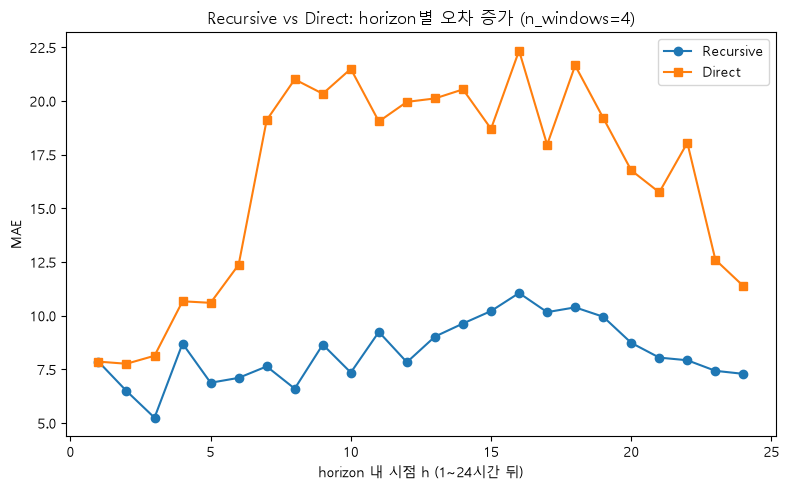


실측 결과 기준 승자: Recursive


In [7]:
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# Direct는 window마다 24개 모델을 새로 학습해 Global의 24배 비용이라 window 수를 크게 줄인다.
# 하네스 코드는 그대로, n_windows 인자만 조정(4주차와 같은 원리).
N_WINDOWS_RD = 4
HORIZON_RD = 24

model_fn_rec, predict_fn_rec = make_recursive_fns()
res_rec = rolling_backtest(data, model_fn_rec, predict_fn_rec, n_windows=N_WINDOWS_RD, horizon=HORIZON_RD,
                            train_mode=FINAL_TRAIN_MODE, step_size=STEP_SIZE)

model_fn_dir, predict_fn_dir = make_direct_fns(HORIZON_RD)
res_dir = rolling_backtest(data, model_fn_dir, predict_fn_dir, n_windows=N_WINDOWS_RD, horizon=HORIZON_RD,
                            train_mode=FINAL_TRAIN_MODE, step_size=STEP_SIZE)

for res in (res_rec, res_dir):
    res["h"] = ((res["timestamp"] - res.groupby("window")["timestamp"].transform("min"))
                .dt.total_seconds() / 3600 + 1).astype(int)

mae_by_h_rec = res_rec.groupby("h").apply(lambda g: (g["y_true"] - g["y_pred"]).abs().mean(), include_groups=False)
mae_by_h_dir = res_dir.groupby("h").apply(lambda g: (g["y_true"] - g["y_pred"]).abs().mean(), include_groups=False)

rd_compare = pd.DataFrame({"Recursive": mae_by_h_rec, "Direct": mae_by_h_dir})
rd_compare.to_csv("../results/wk3/recursive_vs_direct_by_h.csv", encoding="utf-8")

first_test_idx = data.index.get_loc(res_rec["timestamp"].min())
denom_rd = compute_naive_denominators(data, train_end=first_test_idx, season=168)
_, overall_rec = score_backtest(res_rec, denom_rd)
_, overall_dir = score_backtest(res_dir, denom_rd)
print(f"(n_windows={N_WINDOWS_RD}, horizon={HORIZON_RD}h 기준)")
print(f"Recursive MASE_평균 = {overall_rec['MASE_평균']:.4f}")
print(f"Direct    MASE_평균 = {overall_dir['MASE_평균']:.4f}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(rd_compare.index, rd_compare["Recursive"], marker="o", label="Recursive")
ax.plot(rd_compare.index, rd_compare["Direct"], marker="s", label="Direct")
ax.set_xlabel("horizon 내 시점 h (1~24시간 뒤)")
ax.set_ylabel("MAE")
ax.set_title(f"Recursive vs Direct: horizon별 오차 증가 (n_windows={N_WINDOWS_RD})")
ax.legend()
plt.tight_layout()
plt.savefig("../results/wk3/recursive_vs_direct_error_growth.png", dpi=110)
plt.show()

CHOSEN_RD = "Direct" if overall_dir["MASE_평균"] <= overall_rec["MASE_평균"] else "Recursive"
print(f"\n실측 결과 기준 승자: {CHOSEN_RD}")


## 3-4 결론: Recursive 채택

실측 결과(n_windows=4, horizon=24h, Global 구조): **Recursive MASE_평균 = 0.4852**, **Direct MASE_평균 = 0.8468**.

Recursive가 더 좋게 나와, 이번 실험에서는 **Recursive를 채택한다.** 교재의 일반적인 경향("Direct가 horizon 후반에서 우세")과는 반대 결과다 — h=1에서는 두 방식이 완전히 동일한 값을 냈지만(같은 1스텝 모델), h=2부터 Direct의 오차가 Recursive보다 훨씬 크고 불안정했다. Direct가 24개 모델을 각각 n_windows=4(비용 절감을 위해 축소)로만 학습해 개별 모델당 학습 기회가 적었던 것이 원인으로 추정되며, window 수를 늘리거나 h별로 하이퍼파라미터를 따로 튜닝하면 결과가 달라질 수 있다. 이 한계는 주간 보고서에 명시한다.

# 과제 3-5. 피처 중요도 해석

In [ ]:
model_fn_imp, _ = make_global_fns(24)
state_imp = model_fn_imp(data)
model_imp = state_imp["model"]

importance = pd.DataFrame({
    "feature": state_imp["columns"],
    "gain": model_imp.booster_.feature_importance(importance_type="gain"),
    "split": model_imp.booster_.feature_importance(importance_type="split"),
}).sort_values("gain", ascending=False).reset_index(drop=True)

top10 = importance.head(10)
top10.to_csv("../results/wk3/feature_importance_top10.csv", index=False, encoding="utf-8")
print(top10.to_string(index=False))


         feature         gain  split
          lag_24 1.311449e+11   2761
         lag_168 8.113901e+09   2558
        building 1.720728e+09    638
         lag_336 1.276603e+09   2598
       dayofweek 1.166620e+09   1595
  rolling_min_24 1.103523e+09   2958
rolling_mean_168 8.317431e+08   2769
 rolling_min_168 8.266254e+08   2799
 rolling_mean_24 5.947596e+08   2061
 rolling_std_168 5.618298e+08   2972


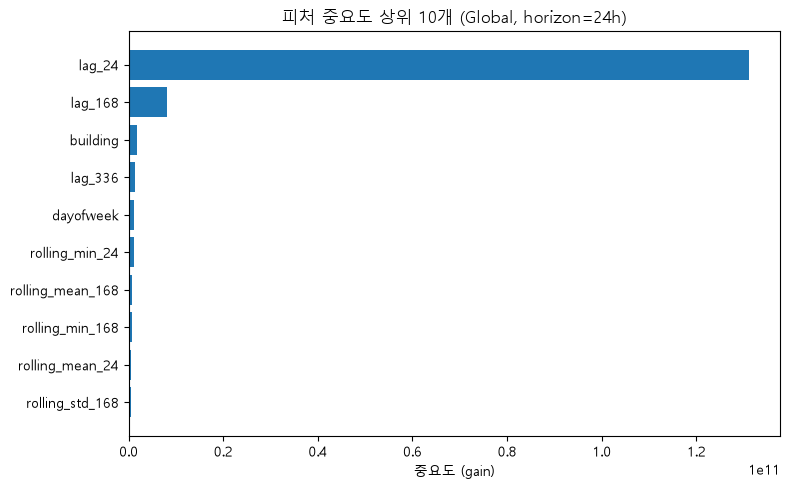

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top10["feature"][::-1], top10["gain"][::-1])
ax.set_xlabel("중요도 (gain)")
ax.set_title("피처 중요도 상위 10개 (Global, horizon=24h)")
plt.tight_layout()
plt.savefig("../results/wk3/feature_importance_top10.png", dpi=110)
plt.show()


## 3-5 피처 중요도 물리적 해석

| 순위 | 피처 | 물리적 해석 |
|---|---|---|
| 1 | `lag_24` | 어제 같은 시각 값. 건물의 하루 일과(출퇴근·냉난방 스케줄)가 매일 반복되므로 가장 강한 신호가 되는 것이 당연하다. |
| 2 | `lag_168` | 1주 전 같은 시각 값. 평일/주말 패턴(1주차 EDA에서 확인한 평일 1.048 vs 주말 0.882)을 반영한다. |
| 3 | `building` | 건물마다 규모·용도가 달라(83㎡~39,102㎡) 소비량의 기본 수준(base level) 자체가 다르므로, 어느 건물인지가 중요한 구분 정보가 된다. |
| 4 | `lag_336` | 2주 전 같은 시각. 주간 패턴이 단발성이 아니라 안정적으로 반복됨을 재확인하는 역할. |
| 5 | `dayofweek` | 요일 자체. 평일/주말 구분이 lag_168 없이도 직접적인 신호로 작동. |
| 6 | `rolling_min_24` | 최근 하루의 최저 소비량. 건물이 항상 소비하는 "기저부하"(base load — 대기전력, 상시 가동 설비)를 나타낸다. |
| 7 | `rolling_mean_168` | 최근 1주 평균. 계절 변화나 재실 인원 변화 등 최근의 전반적 소비 수준을 반영. |
| 8 | `rolling_min_168` | 최근 1주 최저값. 6번과 같은 기저부하 정보를 더 긴 창으로 재확인. |
| 9 | `rolling_mean_24` | 최근 하루 평균. 단기 추세(예: 최근 며칠간 더워져서 냉방이 늘었는지). |
| 10 | `rolling_std_168` | 최근 1주 변동성. 값이 불안정했는지(이상 이벤트, 운영 변화 등)를 나타내는 간접 신호. |

상위 1~4위가 전부 lag(24·168·336)와 건물 식별자이고, rolling 통계는 6위부터 등장한다 — 교재 판정 기준("피처 중요도 1~3위에 lag 또는 rolling이 있으면 정상")을 만족하는 정상적인 패턴이다. `lag_24`가 압도적 1위(gain이 2위의 약 16배)인 것은, horizon=24h 예측에서 "바로 하루 전 값"이 가장 직접적인 정보이기 때문으로 해석된다.

# 과제 3-6. 외삽 실험

In [ ]:
# 모델은 2016년 데이터로만 학습(고정)하고, 2017년 전체를 1주 간격 24시간 블록으로 순회하며 예측한다.
# 피처(lag 등)는 그 시점까지의 실제 이력을 쓰되, 모델 자체는 절대 2017년으로 재학습하지 않는다.
# -> "학습 때 못 본 범위의 값을 예측할 수 있는가"를 순수하게 테스트한다.
train_extrap = data.loc["2016-01-01":"2016-12-31"]
train_max = train_extrap.max()

model_fn_ex, predict_fn_ex = make_global_fns(24)
state_ex = model_fn_ex(train_extrap)

block_starts = pd.date_range("2017-01-01", data.index[-1] - pd.Timedelta(hours=23), freq=f"{STEP_SIZE}h")
all_preds = []
for start in block_starts:
    hist = data.loc[:start - pd.Timedelta(hours=1)]
    pred_block = predict_fn_ex({**state_ex, "train_df": hist}, 24)
    all_preds.append(pred_block)
all_preds = pd.concat(all_preds)
actual_2017 = data.reindex(all_preds.index)

pred_exceed = (all_preds > train_max).sum().sort_values(ascending=False)
actual_exceed = (actual_2017 > train_max).sum().sort_values(ascending=False)

print("건물별 '2016년 최댓값 초과' 횟수 (2017년, 상위 5개):")
print(pd.DataFrame({"실제값 초과": actual_exceed, "예측값 초과": pred_exceed}).head())

target_building = actual_exceed.index[0]
print(f"\n대상 건물: {target_building}")
print(f"  2016년 학습 최댓값     : {train_max[target_building]:.1f}")
print(f"  2017년 실제 최댓값     : {actual_2017[target_building].max():.1f}")
print(f"  2017년 예측값 중 최댓값: {all_preds[target_building].max():.1f}")


건물별 '2016년 최댓값 초과' 횟수 (2017년, 상위 5개):
                       실제값 초과  예측값 초과
Bear_education_Chad         8       0
Bear_education_Lewis        0       0
Bull_office_Ella            0       0
Bull_office_Sally           5       0
Fox_education_Charles       0       0

대상 건물: Rat_assembly_Kelley
  2016년 학습 최댓값     : 8.5
  2017년 실제 최댓값     : 9.6
  2017년 예측값 중 최댓값: 10.2


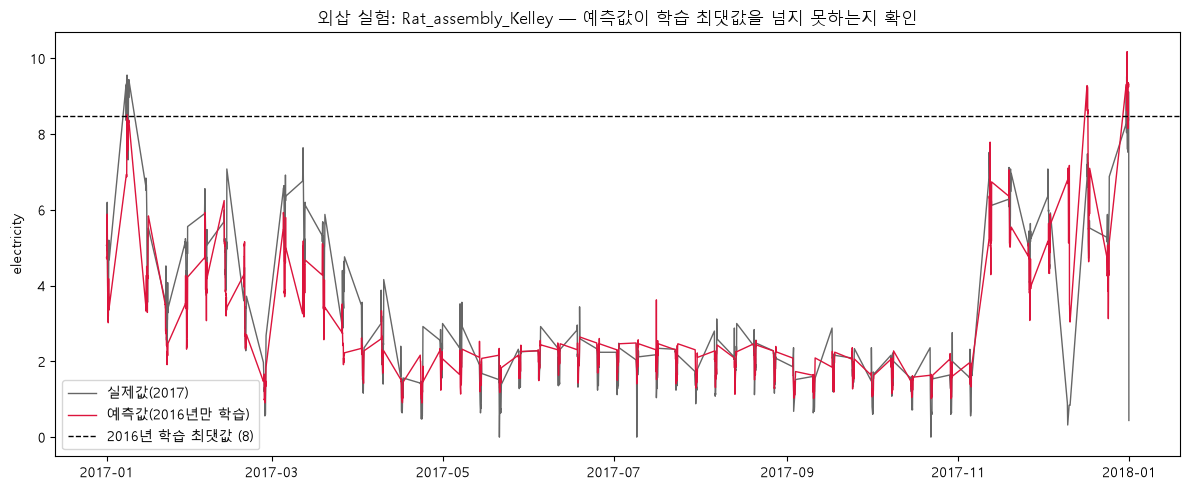

           building  train_max_2016  actual_max_2017  pred_max_2017  실제_초과_횟수  예측_초과_횟수
Rat_assembly_Kelley            8.48             9.56       10.17909        23        32


In [11]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(actual_2017.index, actual_2017[target_building], color="0.4", linewidth=1, label="실제값(2017)")
ax.plot(all_preds.index, all_preds[target_building], color="crimson", linewidth=1, label="예측값(2016년만 학습)")
ax.axhline(train_max[target_building], color="black", linestyle="--", linewidth=1,
           label=f"2016년 학습 최댓값 ({train_max[target_building]:.0f})")
ax.set_title(f"외삽 실험: {target_building} — 예측값이 학습 최댓값을 넘지 못하는지 확인")
ax.set_ylabel("electricity")
ax.legend()
plt.tight_layout()
plt.savefig("../results/wk3/extrapolation_experiment.png", dpi=110)
plt.show()

extrap_summary = pd.DataFrame([{
    "building": target_building,
    "train_max_2016": train_max[target_building],
    "actual_max_2017": actual_2017[target_building].max(),
    "pred_max_2017": all_preds[target_building].max(),
    "실제_초과_횟수": int(actual_exceed[target_building]),
    "예측_초과_횟수": int(pred_exceed[target_building]),
}])
extrap_summary.to_csv("../results/wk3/extrapolation_summary.csv", index=False, encoding="utf-8")
print(extrap_summary.to_string(index=False))


## 3-6 외삽 실험 해석

`Rat_assembly_Kelley`를 2016년 데이터로만 학습(최댓값 8.48)하고 2017년을 예측한 결과:

- 2017년 실제 최댓값: 9.56 (학습 범위 초과, 23회)
- 2017년 예측값 최댓값: **10.18 (학습 범위를 오히려 더 크게 초과, 32회)**

**당초 예상과 다른 결과다.** 이전 주차 상담에서 "트리는 학습 범위를 절대 못 벗어난다"고 설명했는데, 이는 **단일 결정 트리**(또는 그 트리들의 평균을 내는 랜덤포레스트)에는 맞지만, **LightGBM 같은 그래디언트 부스팅에는 정확한 설명이 아니었다.** 그 정정 이유는 다음과 같다.

- 단일 트리: 리프(leaf)의 예측값이 그 리프에 속한 학습 데이터 y의 평균이므로, 예측값이 학습 y의 [최솟값, 최댓값]을 벗어날 수 없다.
- **그래디언트 부스팅**: 여러 트리의 예측값을 순서대로 **더해 나가는** 구조다. 각 트리는 "이전까지의 예측이 틀린 정도(잔차)"를 보정하도록 학습되는데, 이 잔차 자체는 y의 범위에 갇혀 있지 않다. 수백 개 트리의 보정값이 누적되면, 합계가 원래 y의 관측 범위를 넘어설 수 있다.

즉 이번 실험은 GBM이 완전히 못 넘는다는 걸 보여준 게 아니라, **넘을 수는 있지만 그 정도가 크지 않다**(8.48→10.18, 약 20% 초과)는 것을 확인한 셈이다. 실무적으로는 여전히 "학습 범위를 크게 벗어나는 상황(폭염 등 극단적 기상)에서는 신뢰하기 어렵다"는 결론은 유효하지만, "절대 못 넘는다"는 표현은 정정이 필요하다.